In [5]:
# Schritt 1: Repository installieren
!pip install -q git+https://github.com/apple/ml-mobileclip.git

# Schritt 2: Gewichte herunterladen
!wget -P /content/drive/MyDrive/ https://docs-assets.developer.apple.com/ml-research/datasets/mobileclip/mobileclip_s1.pt

  Preparing metadata (setup.py) ... done
--2026-04-27 07:40:26--  https://docs-assets.developer.apple.com/ml-research/datasets/mobileclip/mobileclip_s1.pt
Resolving docs-assets.developer.apple.com (docs-assets.developer.apple.com)... 17.253.31.133, 17.253.31.138, 2620:149:a06:f000::137, ...
Connecting to docs-assets.developer.apple.com (docs-assets.developer.apple.com)|17.253.31.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 340784294 (325M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/mobileclip_s1.pt.1’

mobileclip_s1.pt.1  100%[===================>] 325.00M   323MB/s    in 1.0s    

2026-04-27 07:40:27 (323 MB/s) - ‘/content/drive/MyDrive/mobileclip_s1.pt.1’ saved [340784294/340784294]



In [7]:
import mobileclip
help(mobileclip.create_model_and_transforms)

Help on function create_model_and_transforms in module mobileclip:

create_model_and_transforms(model_name: str, pretrained: Optional[str] = None, reparameterize: Optional[bool] = True, device: Union[str, torch.device] = 'cpu') -> Tuple[torch.nn.modules.module.Module, Any, Any]
    Method to instantiate model and pre-processing transforms necessary for inference.

    Args:
        model_name: Model name. Choose from ['mobileclip_s0', 'mobileclip_s1', 'mobileclip_s2', 'mobileclip_b']
        pretrained: Location of pretrained checkpoint.
        reparameterize: When set to True, re-parameterizable branches get folded for faster inference.
        device: Device identifier for model placement.

    Returns:
        Tuple of instantiated model, and preprocessing transforms for inference.



In [8]:
!pip install -q git+https://github.com/apple/ml-mobileclip.git Pillow scikit-learn seaborn tqdm

  Preparing metadata (setup.py) ... done


In [9]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [10]:
import os
import shutil
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError
import mobileclip

# Gerät wählen
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Gerät: {device}")

# MobileCLIP-S1 laden
weights_path = "/content/drive/MyDrive/mobileclip_s1.pt"  # ← Pfad anpassen!
model, _, preprocess = mobileclip.create_model_and_transforms(
    'mobileclip_s1',
    pretrained=weights_path,
    device=device
)
model.eval()
print("Modell geladen: MobileCLIP-S1")

Gerät: cuda
Modell geladen: MobileCLIP-S1


In [11]:
import mobileclip

categories = ["indoor", "outdoor"]

# Mixed Prompts (empfohlen nach Liao et al. 2025)
category_texts = [
    "a photo taken inside a room showing walls, ceiling, furniture, artificial lighting or floor",
    "a photo taken outdoors showing open spaces such as nature, sky, streets, buildings, parks or landscapes"
]

# Alternativ: Simple Prompts
# category_texts = [
#     "This is an indoor photo.",
#     "This is an outdoor photo."
# ]

# Text tokenisieren
tokenizer = mobileclip.get_tokenizer('mobileclip_s1')
text_tokens = tokenizer(category_texts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Kategorien:", categories)
print("Text-Embeddings berechnet:", text_features.shape)

Kategorien: ['indoor', 'outdoor']
Text-Embeddings berechnet: torch.Size([2, 512])


In [ ]:
# Pfad anpassen!
image_folder = "/content/drive/MyDrive/flickr_data_subset/inside_outside_photos"

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_paths = []

for fname in sorted(os.listdir(image_folder)):
    if fname.startswith("augmented_"):
        continue
    ext = os.path.splitext(fname)[1].lower()
    if ext not in VALID_EXTENSIONS:
        continue
    fpath = os.path.join(image_folder, fname)
    if os.path.isfile(fpath):
        image_paths.append(fpath)

print(f"Bilder gefunden: {len(image_paths)}")

Bilder gefunden: 1009


In [ ]:
def safe_open(path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError) as e:
        print(f"  ⚠ Skipped ({os.path.basename(path)}): {e}")
        return None

BATCH_SIZE = 32

results     = []
confidences = []
valid_paths = []

for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Batches"):
    batch_paths = image_paths[i : i + BATCH_SIZE]

    loaded = [(p, safe_open(p)) for p in batch_paths]
    loaded = [(p, img) for p, img in loaded if img is not None]

    if not loaded:
        continue

    paths_ok, imgs_ok = zip(*loaded)

    # MobileCLIP preprocess anwenden
    img_tensors = torch.stack([preprocess(img) for img in imgs_ok]).to(device)

    with torch.no_grad():
        image_features = model.encode_image(img_tensors)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarities = image_features @ text_features.T

    batch_preds = similarities.argmax(dim=1).cpu().numpy()
    batch_conf  = similarities.max(dim=1).values.cpu().float().numpy()

    results.extend([categories[idx] for idx in batch_preds])
    confidences.extend(batch_conf)
    valid_paths.extend(paths_ok)

print(f"\nClassified: {len(results)} images")
print("\nDistribution:")
for cat in categories:
    print(f"  {cat}: {results.count(cat)}")

Batches: 100%|██████████| 32/32 [08:43<00:00, 16.35s/it]


Classified: 1009 images

Distribution:
  indoor: 38
  outdoor: 971


In [ ]:
output_base = "/content/drive/MyDrive/flickr_data_subset/mobileclip_sorted"

sorted_dirs = {cat: os.path.join(output_base, cat) for cat in categories}
for d in sorted_dirs.values():
    os.makedirs(d, exist_ok=True)

for path, pred in zip(valid_paths, results):
    shutil.copy(path, sorted_dirs[pred])

print("Images sorted:")
for cat in categories:
    count = results.count(cat)
    print(f"  {cat}: {count} images → {sorted_dirs[cat]}")

Images sorted:
  indoor: 38 images → /content/drive/MyDrive/flickr_data_subset/mobileclip_sorted/indoor
  outdoor: 971 images → /content/drive/MyDrive/flickr_data_subset/mobileclip_sorted/outdoor


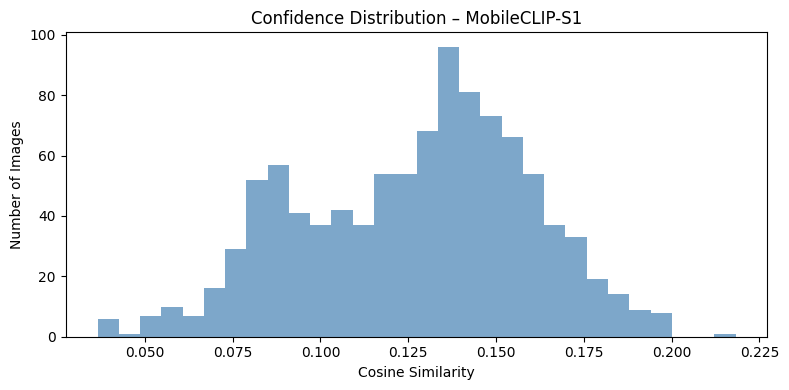

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(confidences, bins=30, alpha=0.7, color="steelblue")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence Distribution – MobileCLIP-S1")
plt.tight_layout()
plt.show()

In [ ]:
output_csv = "/content/drive/MyDrive/flickr_data_subset/mobileclip_sorted/mobileclip_labels.csv"

df_results = pd.DataFrame({
    "file_name":  [os.path.basename(p) for p in valid_paths],
    "pred_label": results,
    "confidence": confidences
})

df_results.to_csv(output_csv, index=False)
print(f"Labels saved: {output_csv}")
print()
print("Distribution:")
print(df_results["pred_label"].value_counts())
print(f"\nTotal: {len(df_results)} images")

Labels saved: /content/drive/MyDrive/flickr_data_subset/mobileclip_sorted/mobileclip_labels.csv

Distribution:
pred_label
outdoor    971
indoor      38
Name: count, dtype: int64

Total: 1009 images


Evaluable images: 1007

Accuracy:        0.9255
Avg Confidence:  0.1270

              precision    recall  f1-score   support

      indoor       0.97      0.33      0.49       110
     outdoor       0.92      1.00      0.96       897

    accuracy                           0.93      1007
   macro avg       0.95      0.66      0.72      1007
weighted avg       0.93      0.93      0.91      1007



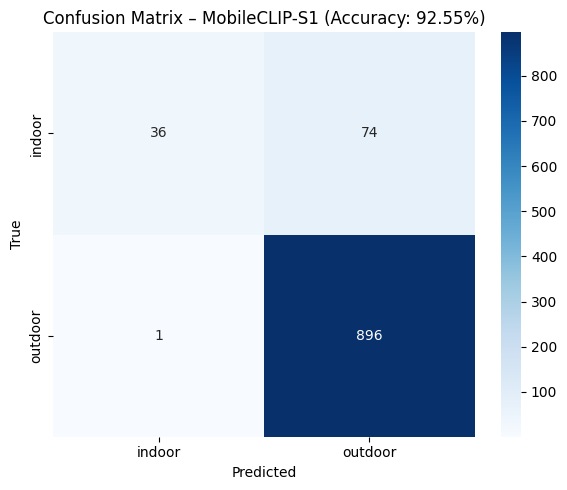

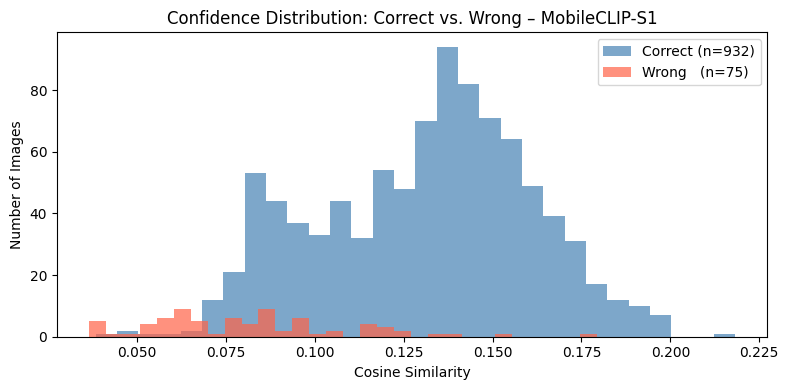


Top 10 most uncertain images:
            file_name true_label pred_label  confidence
777    image_6336.jpg     indoor    outdoor    0.036534
798     image_744.jpg     indoor    outdoor    0.036562
778    image_6337.jpg     indoor    outdoor    0.037336
620      image_25.jpg     indoor    outdoor    0.037909
735      image_45.jpg    outdoor    outdoor    0.038324
1001   image_9231.jpg     indoor    outdoor    0.038685
617    image_2321.jpg     indoor    outdoor    0.045084
755    image_5488.jpg     indoor    outdoor    0.048737
486   image_11647.jpg     indoor     indoor    0.049503
489   image_11650.jpg     indoor     indoor    0.049503

── All files saved to: /content/drive/MyDrive/flickr_data_subset/mobileclip_sorted/evaluation ──
  mobileclip_metrics.csv
  mobileclip_confusion_matrix.png
  mobileclip_confidence_distribution.png
  mobileclip_most_uncertain.csv


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

output_dir = "/content/drive/MyDrive/flickr_data_subset/mobileclip_sorted/evaluation"
os.makedirs(output_dir, exist_ok=True)

label_csv   = "/content/drive/MyDrive/flickr_data_subset/flickr_photos_sorted/photo_labels_indoor_outdoor_17042026.csv"
df_labels   = pd.read_csv(label_csv)
labels_dict = dict(zip(df_labels["file_name"], df_labels["Main_focus"]))

df_results["true_label"] = df_results["file_name"].map(labels_dict)
df_eval = df_results.dropna(subset=["true_label"])
print(f"Evaluable images: {len(df_eval)}")

true     = df_eval["true_label"].values
pred     = df_eval["pred_label"].values
accuracy = accuracy_score(true, pred)
avg_conf = float(np.mean(df_eval["confidence"]))

print(f"\nAccuracy:        {accuracy:.4f}")
print(f"Avg Confidence:  {avg_conf:.4f}")
print()
report = classification_report(true, pred,
                                target_names=sorted(categories),
                                output_dict=True)
print(classification_report(true, pred, target_names=sorted(categories)))

pd.DataFrame(report).transpose().to_csv(
    os.path.join(output_dir, "mobileclip_metrics.csv"))

le = LabelEncoder()
le.classes_ = np.array(sorted(categories))
cm = confusion_matrix(le.transform(true), le.transform(pred))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – MobileCLIP-S1 (Accuracy: {accuracy:.2%})")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "mobileclip_confusion_matrix.png"),
            dpi=150, bbox_inches='tight')
plt.show()

correct      = (df_eval["true_label"] == df_eval["pred_label"]).tolist()
conf_correct = [c for c, ok in zip(df_eval["confidence"], correct) if ok]
conf_wrong   = [c for c, ok in zip(df_eval["confidence"], correct) if not ok]

plt.figure(figsize=(8, 4))
plt.hist(conf_correct, bins=30, alpha=0.7,
         label=f"Correct (n={len(conf_correct)})", color="steelblue")
plt.hist(conf_wrong,   bins=30, alpha=0.7,
         label=f"Wrong   (n={len(conf_wrong)})",   color="tomato")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Images")
plt.title("Confidence Distribution: Correct vs. Wrong – MobileCLIP-S1")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "mobileclip_confidence_distribution.png"),
            dpi=150, bbox_inches='tight')
plt.show()

df_uncertain = df_eval.nsmallest(10, "confidence")[
    ["file_name", "true_label", "pred_label", "confidence"]]
print("\nTop 10 most uncertain images:")
print(df_uncertain)
df_uncertain.to_csv(os.path.join(output_dir, "mobileclip_most_uncertain.csv"), index=False)

print(f"\n── All files saved to: {output_dir} ──")
print("  mobileclip_metrics.csv")
print("  mobileclip_confusion_matrix.png")
print("  mobileclip_confidence_distribution.png")
print("  mobileclip_most_uncertain.csv")